import IBM AMLSim

In [1]:
from loader.dataset_factory import DatasetFactory

# Inizializza il loader specificando il nome canonico del dataset
loader = DatasetFactory.get_loader("ibm_amlsim")

# Carica i dati in memoria (file delle transazioni e, se presente, degli account)
loader.load()

# Stampa un riepilogo conciso del dataset caricato per verificare che sia tutto ok
loader.summary()

Loading IBM AMLSim transactions from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\loader\..\data\ibm_amlsim\HI-Small_Trans.csv
  Loaded 5,078,345 rows.
Loading IBM AMLSim accounts from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\loader\..\data\ibm_amlsim\HI-Small_accounts.csv
  Loaded 518,581 account records.
  Dataset : IBMAMLSimLoader
  Rows    : 5,078,345
  Columns : 11
  Fraud   : 5,177  (0.1019 %)



In [2]:
loader.print_features()



Column               Type         Description
--------------------------------------------------------------------------------
Timestamp            object       Date and time of the transaction
From Bank            int64        Numeric identifier of the originating bank  (e.g. [1, 10, 12, 3208, 3209])
Account              object       Hexadecimal ID of the sender account (node)
To Bank              int64        Numeric identifier of the receiving bank  (e.g. [1, 10, 12, 2439, 3209])
Account.1            object       Hexadecimal ID of the receiver account (node)
Amount Received      float64      Transaction amount in the receiving currency
Receiving Currency   object       Currency received by the destination account  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee'])
Amount Paid          float64      Transaction amount in the paying currency
Payment Currency     object       Currency used by the sender  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Doll

Data preparation

In [3]:
from data_preparation import DataPreparation

# Otteniamo il dataframe raw delle transazioni dal nostro loader
transactions_df = loader.get_transactions()

# Inizializziamo la classe scegliendo il robust scaler
data_prep = DataPreparation(scaler_type='robust')

# 1. Calcoliamo le feature standardizzate per le transazioni (gli archi E)
edges_features_df = data_prep.fit_transform_edges(transactions_df)

# 2. Aggreghiamo le transazioni per ricavare l'embedding iniziale dei nodi (V)
nodes_features_df = data_prep.get_node_features(edges_features_df)

print(f"Dimensione feature archi: {edges_features_df.shape}")
print(f"Dimensione feature nodi: {nodes_features_df.shape}")


Extracting time features (Unix time, Cyclic Hour, Day of Week)...
Applying edge transformation (Amounts: robust, Time: standard)...
Aggregating node features and extracting ground truth labels...
Dimensione feature archi: (5078345, 52)
Dimensione feature nodi: (515080, 49)



### GAGNN Model Setup & Hyperparameters

Below are the key hyperparameters for the GAGNN implementation. All values are defined in the code cell below.

**Model Architecture:**
- `node_in_dim`: Dimension of input node features (inferred from data).
- `edge_feat_dim`: Dimension of edge features (inferred from data).
- `hidden_dim`: Hidden dimension for GAT layers (from paper's GAT#1 units).
- `out_dim`: Output dimension of the community-centric encoder.
- `heads`: Number of attention heads $k$ (as per paper).
- `beta`: Trade-off parameter for eMRF similarity.

**Loss Optimization ($\mathcal{L} = \eta \mathcal{L}_{group} + \lambda \mathcal{L}_{node} + \zeta \mathcal{L}_{trans}$):**
- `eta`: Weight for the group-level loss term.
- `lambda_`: Weight for the node-level loss term.
- `zeta`: Weight for the transaction-level loss term.

**Training:**
- `learning_rate`: Learning rate for the Adam optimizer (from paper).
- `epochs`: Number of full passes over the training batches.

**Mini-batch Sampling (NeighborLoader):**
- `batch_size`: Number of seed nodes processed per mini-batch.
- `num_neighbors`: List of neighbors sampled per hop for each GAT layer. Length must match the number of GAT layers (2).


In [4]:
# =============================================================================
# Hyperparameters — edit these values to configure the model and training
# =============================================================================

# Model Architecture
hidden_dim      = 64       # Hidden dimension for GAT layers
out_dim         = 64       # Output dimension of community-centric encoder
heads           = 5        # Number of GAT attention heads (k=5 as per paper)
beta            = 0.44     # eMRF trade-off parameter
mlp_hidden_dim  = 64       # Hidden dimension for the edge classification MLP
nn_t_hidden_dim = 128      # Hidden dimension for node classification MLP

# Loss weights
eta             = 1.0      # Group loss weight
lambda_         = 1.0      # Node loss weight
zeta            = 1.0      # Transaction loss weight

# Training
learning_rate   = 0.001    # Adam optimizer learning rate
epochs          = 100      # Maximum number of training epochs
patience        = 100      # Early stopping patience (epochs without val improvement)
minibatches     = True     # Whether to train with minibatches or full graph

# Mini-batch Sampling
batch_size      = 128      # Seed nodes per batch
sampling_prob   = 0.5      # Bernoulli distribution probability for keeping neighbors
num_neighbors   = [-1, -1] # Neighbors sampled per hop for each GAT layer

# Class Imbalance
downsample      = True     # Down-sample majority class (legitimate nodes) in training set

In [5]:
import torch
import numpy as np

# 1. Map string Account IDs to integers (0 to N-1) for PyTorch Geometric
unique_nodes = nodes_features_df.index.unique()
node_mapping = {node_id: idx for idx, node_id in enumerate(unique_nodes)}

# 2. Extract edge_index
src = edges_features_df['Account'].map(node_mapping).values
dst = edges_features_df['Account.1'].map(node_mapping).values
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)

# 3. Extract edge features and transaction labels
edge_features_cols = [c for c in edges_features_df.columns if c not in ['Account', 'Account.1', 'Is Laundering']]
edge_attr = torch.tensor(edges_features_df[edge_features_cols].values, dtype=torch.float)
y_trans = torch.tensor(edges_features_df['Is Laundering'].values, dtype=torch.float).unsqueeze(1)

# 4. Extract node features and node labels
node_features_cols = [c for c in nodes_features_df.columns if c != 'Is Laundering']
x = torch.tensor(nodes_features_df[node_features_cols].values, dtype=torch.float)

# If a node was involved in at least one ML transaction, label it as 1 (suspicious)
y_node = torch.tensor(nodes_features_df['Is Laundering'].values, dtype=torch.float)  # Soft probability (paper Eq. 2)

print(f"Node features shape: {x.shape}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Edge features shape: {edge_attr.shape}")


Node features shape: torch.Size([515080, 48])
Edge index shape: torch.Size([2, 5078345])
Edge features shape: torch.Size([5078345, 49])


In [6]:
from model.gagnn import GAGNN
from model.loss import GAGNNLoss

# Ensure device is set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move tensors to device
x = x.to(device)
edge_index = edge_index.to(device)
edge_attr = edge_attr.to(device)
y_node = y_node.to(device)
y_trans = y_trans.to(device)
num_edges = edge_index.shape[1]

# Instantiate Model
model = GAGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=hidden_dim,
    out_dim=out_dim,
    heads=heads,
    beta=beta,
    mlp_hidden_dim=mlp_hidden_dim,
    nn_t_hidden_dim=nn_t_hidden_dim,
    minibatches=minibatches
).to(device)

# Instantiate Loss and Optimizer
criterion = GAGNNLoss(eta=eta, lambda_=lambda_, zeta=zeta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(model)


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GAGNN(
  (encoder): CommunityCentricEncoder(
    (gat1): GATConv(48, 64, heads=5)
    (gat2): GATConv(64, 64, heads=5)
    (emrf): eMRFLayer(
      (H2): Linear(in_features=64, out_features=64, bias=False)
    )
    (nn_t): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
    (coarse_classifier): Linear(in_features=64, out_features=1, bias=True)
  )
  (group_layer): GroupRepresentationLayer(
    (mlp): Sequential(
      (0): Linear(in_features=177, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (group_proj): Linear(in_features=64, out_features=48, bias=True)
)


In [7]:
import os
import numpy as np
import torch
from utils import get_random_splits
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.utils import dropout_adj

# --- Train / Val / Test Split Masks (70 / 10 / 20) with stratified random split ---
n_nodes = x.shape[0]
train_idx, val_idx, test_idx = get_random_splits(y_node, n_nodes, val_size=0.1, test_size=0.2)

def make_mask(indices, n):
    mask = torch.zeros(n, dtype=torch.bool)
    mask[indices] = True
    return mask

train_node_mask = make_mask(train_idx, n_nodes)
val_node_mask   = make_mask(val_idx,   n_nodes)
test_node_mask  = make_mask(test_idx,  n_nodes)

print(f"Train nodes : {train_node_mask.sum().item()} ({train_node_mask.sum().item()/n_nodes*100:.1f}%)")
print(f"Val nodes   : {val_node_mask.sum().item()}   ({val_node_mask.sum().item()/n_nodes*100:.1f}%)")
print(f"Test nodes  : {test_node_mask.sum().item()}  ({test_node_mask.sum().item()/n_nodes*100:.1f}%)")
print("-" * 50)

# --- Package graph into a PyG Data object ---
data = Data(
    x=x.cpu(),
    edge_index=edge_index.cpu(),
    edge_attr=edge_attr.cpu(),
    y_node=y_node.cpu(),
    y_trans=y_trans.cpu()
)

if not minibatches:
    # Full graph setup
    data = data.to(device)

# --- Early Stopping State ---
best_val_loss    = float('inf')
patience_counter = 0
model.val_losses = []          # track validation losses

def train_step(data_batch, is_minibatch=True):
    optimizer.zero_grad()
    
    sampled_edge_index, sampled_edge_attr = data_batch.edge_index, data_batch.edge_attr

    p_node, p_trans, p_group, y_group = model(
        data_batch.x, sampled_edge_index, sampled_edge_attr, data_batch.num_edges,
        y_node=data_batch.y_node.view(-1)  # ground-truth for y_group (Diff 7)
    )

    if p_group.numel() > 0:
        if is_minibatch:
            n_seed = data_batch.batch_size
            seed_node_mask = torch.zeros(data_batch.num_nodes, dtype=torch.bool, device=device)
            seed_node_mask[:n_seed] = True
            all_edge_mask = torch.ones(sampled_edge_index.shape[1], dtype=torch.bool, device=device)
        else:
            seed_node_mask = train_node_mask.to(device)
            all_edge_mask = None # compute loss on all sampled edges

        loss, l_node, l_trans, l_group = criterion(
            p_node, data_batch.y_node.view(-1, 1),
            p_trans, data_batch.y_trans if not is_minibatch else data_batch.y_trans[:sampled_edge_attr.size(0)], # Approx if full graph
            p_group, y_group,
            node_mask=seed_node_mask,
            trans_mask=all_edge_mask
        )

        loss.backward()
        optimizer.step()
        return loss.item()
    return 0.0

def val_step(data_batch, is_minibatch=True):
    with torch.no_grad():
        p_node, p_trans, p_group, y_group = model(
            data_batch.x, data_batch.edge_index, data_batch.edge_attr, data_batch.num_edges
        )
        if p_group.numel() > 0:
            if is_minibatch:
                n_seed = data_batch.batch_size
                seed_node_mask = torch.zeros(data_batch.num_nodes, dtype=torch.bool, device=device)
                seed_node_mask[:n_seed] = True
                all_edge_mask = torch.ones(data_batch.edge_index.shape[1], dtype=torch.bool, device=device)
            else:
                seed_node_mask = val_node_mask.to(device)
                all_edge_mask = None
                
            val_loss, *_ = criterion(
                p_node, data_batch.y_node.view(-1, 1),
                p_trans, data_batch.y_trans,
                p_group, y_group,
                node_mask=seed_node_mask,
                trans_mask=all_edge_mask
            )
            return val_loss.item()
    return 0.0


# --- Training Loop with Early Stopping ---
for epoch in range(epochs):

    if minibatches:
        # Bernoulli neighbor sampling applied globally to limit computation
        edge_mask = torch.rand(data.edge_index.size(1), device=data.edge_index.device) > (1.0 - sampling_prob)
        sampled_edge_index = data.edge_index[:, edge_mask]
        sampled_edge_attr = data.edge_attr[edge_mask]
        sampled_y_trans = data.y_trans[edge_mask]
        temp_data = Data(x=data.x, edge_index=sampled_edge_index, edge_attr=sampled_edge_attr, y_node=data.y_node, y_trans=sampled_y_trans)
        train_loader = NeighborLoader(
            temp_data, num_neighbors=num_neighbors, batch_size=batch_size,
            input_nodes=train_node_mask.cpu(), shuffle=True
        )
        val_loader = NeighborLoader(
            temp_data, num_neighbors=num_neighbors, batch_size=batch_size,
            input_nodes=val_node_mask.cpu(), shuffle=False
        )

    # ── Train ────────────────────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    if minibatches:
        for batch in train_loader:
            batch = batch.to(device)
            epoch_loss += train_step(batch, is_minibatch=True)
            num_batches += 1
    else:
        epoch_loss += train_step(data, is_minibatch=False)
        num_batches = 1
        
    avg_train_loss = epoch_loss / max(num_batches, 1)
    model.training_losses.append(avg_train_loss)

    # ── Validate ─────────────────────────────────────────────────────────────────────────────
    model.eval()
    val_loss_total = 0.0
    n_val_batches  = 0
    
    if minibatches:
        for batch in val_loader:
            batch = batch.to(device)
            val_loss_total += val_step(batch, is_minibatch=True)
            n_val_batches  += 1
    else:
        val_loss_total += val_step(data, is_minibatch=False)
        n_val_batches = 1
        
    avg_val_loss = val_loss_total / max(n_val_batches, 1)
    model.val_losses.append(avg_val_loss)

    # ── Early Stopping Check ─────────────────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        model.save("saved_models/gagnn_best.pt")
        status = "new best"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{patience}"

    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}  [{status}]")

    if patience_counter >= patience:
        model.save("saved_models/gagnn_patience_trigger.pt")
        print(f"\nEarly stopping triggered after {epoch+1} epochs (no improvement for {patience} epochs).")
        break

print("\nTraining complete. Best model saved to saved_models/gagnn_best.pt")


Extracting Validation Set: 6 pos, 50872 neg
Extracting Test Set:       13 pos, 101744 neg
Extracting Train Set (downsampled): 50 pos, 50 neg
Train nodes : 100 (0.0%)
Val nodes   : 50878   (9.9%)
Test nodes  : 101757  (19.8%)
--------------------------------------------------


C:\Users\marti\AppData\Local\Temp\ipykernel_14360\753693259.py:109: UserWarning: 'dropout_adj' is deprecated, use 'dropout_edge' instead
  sampled_edge_index, sampled_edge_attr = dropout_adj(


IndexError: The shape of the mask [2571] at index 0 does not match the shape of the indexed tensor [5078345, 1] at index 0

    EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.9707
  Precision : 0.0007
  Recall    : 0.0311
  F1-Score  : 0.0013
  ROC-AUC   : 0.5799
--------------------------------------------------
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99    878810
  Laundering       0.00      0.03      0.00       547

    accuracy                           0.97    879357
   macro avg       0.50      0.50      0.49    879357
weighted avg       1.00      0.97      0.98    879357



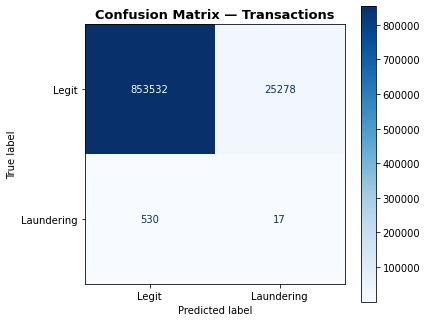

In [ ]:
from model.gagnn import GAGNN
from utils import Evaluator
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GAGNN.load_saved("saved_models/gagnn_best.pt").to(device)

if minibatches:
    Evaluator.evaluation_report(model, test_loader, criterion, device)
else:
    Evaluator.evaluation_report(model, [data], criterion, device) # Wrap data in a list to act like an iterable loader



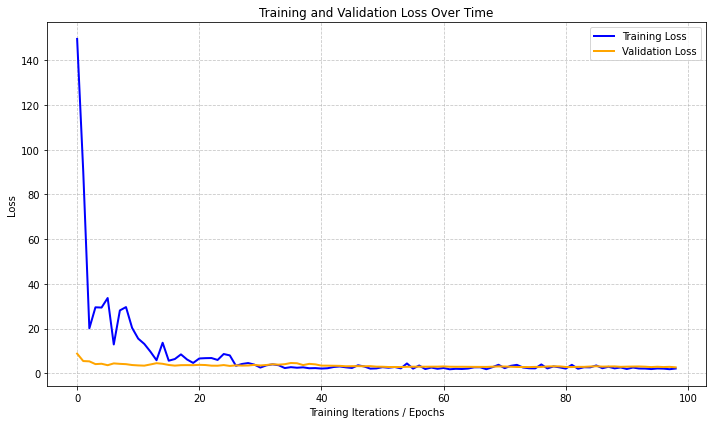

In [ ]:
model.plot_training_history()
